In [4]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

In [5]:
# 1. Load dataset
books = pd.read_excel(r"C:\Users\Suman\Downloads\books.xlsx")
print("Shape of dataset:", books.shape)
books.head()

Shape of dataset: (399, 8)


,book_id,authors,original_publication_year,title,language_code,average_rating,image_url,description
0,2767052,Suzanne Collins,2008,"The Hunger Games (The Hunger Games, #1)",eng,4.34,https://images.gr-assets.com/books/1447303603m...,First in the ground-breaking HUNGER GAMES tril...
1,3,"J.K. Rowling, Mary GrandPrÃ©",1997,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,https://images.gr-assets.com/books/1474154022m...,Rescued from the outrageous neglect of his aun...
2,41865,Stephenie Meyer,2005,"Twilight (Twilight, #1)",en-US,3.57,https://images.gr-assets.com/books/1361039443m...,"When 17 year old Isabella Swan moves to Forks,..."
3,2657,Harper Lee,1960,To Kill a Mockingbird,eng,4.25,https://images.gr-assets.com/books/1361975680m...,Harper Lee's classic novel of a lawyer in the ...
4,4671,F. Scott Fitzgerald,1925,The Great Gatsby,eng,3.89,https://images.gr-assets.com/books/1490528560m...,The only authorized edition of the twentieth-c...


In [6]:
books

,book_id,authors,original_publication_year,title,language_code,average_rating,image_url,description
0,2767052,Suzanne Collins,2008,"The Hunger Games (The Hunger Games, #1)",eng,4.34,https://images.gr-assets.com/books/1447303603m...,First in the ground-breaking HUNGER GAMES tril...
1,3,"J.K. Rowling, Mary GrandPrÃ©",1997,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,https://images.gr-assets.com/books/1474154022m...,Rescued from the outrageous neglect of his aun...
2,41865,Stephenie Meyer,2005,"Twilight (Twilight, #1)",en-US,3.57,https://images.gr-assets.com/books/1361039443m...,"When 17 year old Isabella Swan moves to Forks,..."
3,2657,Harper Lee,1960,To Kill a Mockingbird,eng,4.25,https://images.gr-assets.com/books/1361975680m...,Harper Lee's classic novel of a lawyer in the ...
4,4671,F. Scott Fitzgerald,1925,The Great Gatsby,eng,3.89,https://images.gr-assets.com/books/1490528560m...,The only authorized edition of the twentieth-c...
...,...,...,...,...,...,...,...,...
394,2248573,Christopher Paolini,2008,"Brisingr (The Inheritance Cycle, #3)",eng,4.03,https://s.gr-assets.com/assets/nophoto/book/11...,Donâ€™t miss the eagerly anticipated epic new ...
395,56495,Rick Warren,2002,The Purpose Driven Life: What on Earth Am I He...,en-US,3.90,https://s.gr-assets.com/assets/nophoto/book/11...,"Rick Warren helps readers to discover, develop..."
396,676924,"P.C. Cast, Kristin Cast",2007,"Betrayed (House of Night, #2)",en-US,3.93,https://s.gr-assets.com/assets/nophoto/book/11...,"Betrayed, the second installment in the bestse..."
397,47212,Jim Butcher,2000,"Storm Front (The Dresden Files, #1)",en-US,4.02,https://images.gr-assets.com/books/1419456275m...,In the first novel in the #1 New York Times be...


In [7]:
# 2. Basic preprocessing
books = books.dropna(subset=["title"])  
books["Description"] = books["description"].fillna("")

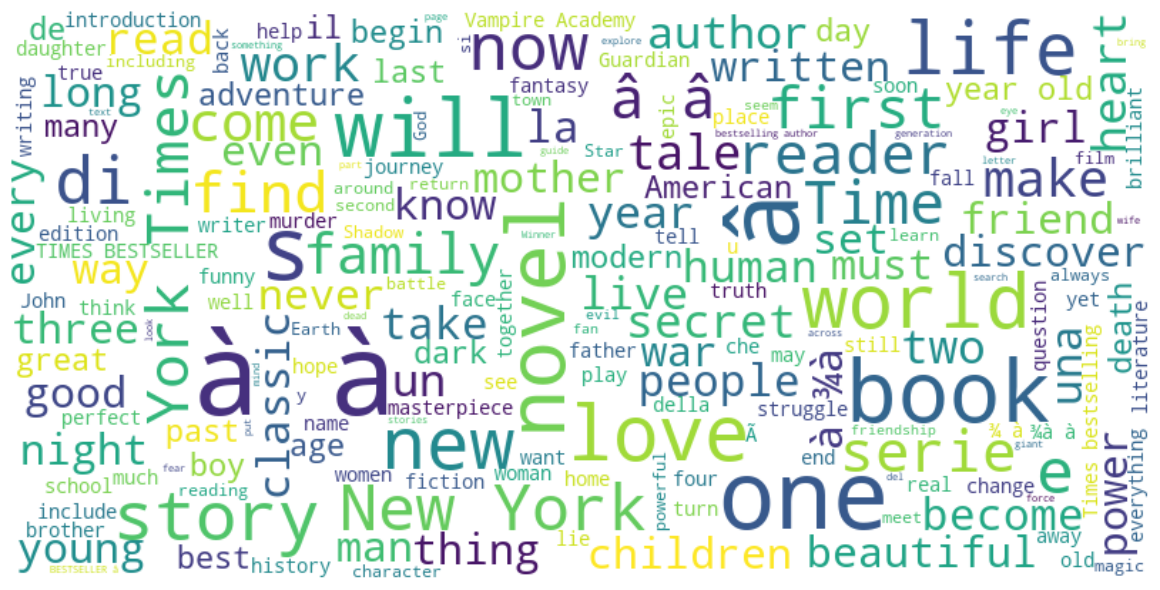

In [8]:
all_descriptions = " ".join(books['description'].dropna().astype(str).values)

stopwords = set(STOPWORDS)

wc = WordCloud(
    background_color='white',
    stopwords=stopwords,
    max_words=200,
    max_font_size=80,
    width=800,
    height=400
).generate(all_descriptions)


plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()

In [9]:
# 3. Content-based recommender (using Description + Title)
books["text_features"] = books["title"] + " " + books["description"]

In [10]:
books['text_features'][10]

'Divergent (Divergent, #1) The explosive debut by No. 1 New York Times bestselling author Veronica Roth. DIVERGENT â€“ a major motion picture series.'

In [11]:
# TF-IDF vectorization
vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(books["text_features"])

# Cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [12]:
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 27880 stored elements and shape (399, 10624)>

In [13]:
# Book index mapping
indices = pd.Series(books.index, index=books["title"].str.lower()).drop_duplicates()

In [14]:
indices

title
the hunger games (the hunger games, #1)                       0
harry potter and the sorcerer's stone (harry potter, #1)      1
twilight (twilight, #1)                                       2
to kill a mockingbird                                         3
the great gatsby                                              4
                                                           ... 
brisingr (the inheritance cycle, #3)                        394
the purpose driven life: what on earth am i here for?       395
betrayed (house of night, #2)                               396
storm front (the dresden files, #1)                         397
the 5th wave (the 5th wave, #1)                             398
Length: 399, dtype: int64

In [15]:
import pickle
with open('titles.pkl', 'wb') as file:
    pickle.dump(indices.index, file)    

In [16]:
import pickle
with open('cos_sim.pkl', 'wb') as file:
    pickle.dump(cosine_sim, file) 

In [17]:

# 4. Recommender function
def recommend_books(title, top_n=5):
    title = title.lower()
    if title not in indices:
        return ["Book not found in dataset"]
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]  # skip the input book itself
    book_indices = [i[0] for i in sim_scores]
    return books.iloc[book_indices]["title"].tolist()


In [18]:
recommend_books("The Maze Runner (Maze Runner, #1)",3)

['The Scorch Trials (Maze Runner, #2)',
 'The Death Cure (Maze Runner, #3)',
 'The Kite Runner']